# BA843: Big Data Analytics - Evolution of Global Music Trends

Group 5: Amonwan Bunyadarba, Zhe-Yu Lin, Tharfeed Ahmed Unus, Yu-Hsiang Wang, Yu Xu

## Project Proposal

This project's purpose is to explore the evolution of global music trends using data from Discogs, one of the largest online music databases of music releases. There are four datasets in total - masters, artists, labels, and releases, which include general information such as release dates, artists, popularity, and more.

Based on these datasets, our goals are to:
+ Identify music genres & artists with highest production rates over the decades.
+ Compare trends across various genres/formats, highlighting significant growth or decline periods.
+ Apply machine learning methods for classification, clustering, and/or text mining to analyze the distribution of genres and themes.
+ Present visualizations and analytical findings that illustrate the evolution of music genres over time and across regions.

By utilizing machine learning techniques in PySpark, this project aims to deliver meaningful visual and analytical insights, understand historical music trends in today’s dynamic music environment.

**Data Sources:**

+ Original Source: https://discogs-data-dumps.s3.us-west-2.amazonaws.com/index.html
+ Kaggle: https://www.kaggle.com/datasets/ofurkancoban/discogs-datasets-january-2025?resource=download

## Introduction & Motivation

**Introduction:**

Music genres are the groups of songs that share similar sounds, instruments, mood and cultural origin—providing a convenient way to categorize and discover music. Over time, these broad categories have fragmented into hundreds of subgenres, each defined by distinct stylistic or historical criteria. Leading streaming platforms like Spotify now recognize numerous genres, and they combine these genre labels with metadata (for example, release date and styles) and real-time user signals (likes, skips, shares) to fuel a highly personalized recommendation engine. This fine-grained classification not only helps listeners find new music they love but also drives engagement and retention at scale, playing a key role in building Spotify into a $20 billion business.


**Motivation:**

In today's fast-paced music industry, the transition from physical media to digital streaming platforms has accelerated the cycle of trends, emerging quickly and fading just as fast. Therefore, understanding the future trajectories and evolution of music genres is more crucial than ever. This project aims to provide deep insights into the progression of music and genres, allowing platforms and companies to anticipate shifts in the landscape of the music industry. By leveraging these insights, stakeholders can enhance user experiences by improving the recommendation systems to unlock innovative engagement strategies through the element of music genres and other insights.

## Executive Summary

In this project, we dive into how the music world has evolved over the years, using data from the Discogs Database. We explored trends across genres, artist profiles, and music formats, uncovering how different periods shaped the global music landscape. Through machine learning models such as logistic regression, SVM, and random forest classifiers, we achieved strong predictive accuracy even with a limited set of features. Our exploratory analysis also revealed important structural patterns in the data, such as the dominance of solo artists and the rise and fall of multi-genre recordings over time. There are clear opportunities where adding more detailed information, including richer textual features and deeper metadata, could further boost model performance and uncover even more nuanced trends.

In practice, this work can help music platforms like Spotify automate genre tagging, better organize their massive song catalogs, and enhance their recommendation engines. It also demonstrates the broader potential of big data analytics to illuminate how music reflects shifting cultural, social, and technological patterns. By combining traditional analysis with machine learning and text mining, we show that it is possible not only to understand the past and present of music but also to anticipate future industry directions. Overall, this project offers valuable insights for stakeholders across the music industry, from streaming platforms to record labels, seeking to stay ahead in an ever-evolving musical landscape. Going forward, this project can be expanded to include more comprehensive fields like release profile, and employing deep learning models can help improve model predictions.

## Initializations and Importations

In [ ]:
!pip install nltk

In [ ]:
from pyspark import SparkContext
from pyspark.sql import SparkSession, functions as F
from pyspark.sql.functions import col, count, desc, from_json, regexp_replace, split, size, substring_index,sum as _sum, when, explode, countDistinct, udf, lower, row_number, collect_list, concat_ws, expr, monotonically_increasing_id, length,regexp_extract
from pyspark.sql.types import StructField, StructType, StringType, LongType, ArrayType, BooleanType
from pyspark.sql.window import Window

from pyspark.ml import Pipeline
from pyspark.ml.feature import StringIndexer, CountVectorizer, IDF, StandardScaler, VectorAssembler
from pyspark.ml.classification import RandomForestClassifier, LogisticRegression, LinearSVC, OneVsRest
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
from pyspark.ml.tuning import ParamGridBuilder, CrossValidator
from pyspark.ml.linalg import SparseVector

import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
from nltk.corpus import stopwords

In [ ]:
import warnings
warnings.filterwarnings("ignore")

In [ ]:
spark = SparkSession \
    .builder \
    .appName("groupproject") \
    .getOrCreate()

25/04/26 23:03:06 WARN SparkSession: Using an existing Spark session; only runtime SQL configurations will take effect.


In [ ]:
# read artists

artist_schema = StructType([
    StructField("aliases_name", StringType(), True),
    StructField("aliases_name_id", StringType(), True),
    StructField("groups_name", StringType(), True),
    StructField("groups_name_id", StringType(), True),
    StructField("members_name", StringType(), True),
    StructField("members_name_id", StringType(), True),
    StructField("namevariations_name", StringType(), True),
    StructField("urls_url", StringType(), True),
    StructField("artist_data_quality", StringType(), True),
    StructField("artist_id", StringType(), True),
    StructField("artist_name", StringType(), True),
    StructField("artist_profile", StringType(), True),
    StructField("artist_realname", StringType(), True)
])

In [ ]:
artists = spark.read.csv(
    path="gs://group5-qst843-spring25-dataproc/data/discogs_20250201_artists.csv",
    header=True,
    schema=artist_schema,
    nullValue="NA",
    quote='"',
    escape='"',
    multiLine=True,
    ignoreLeadingWhiteSpace=True,
    ignoreTrailingWhiteSpace=True
)

# Clean up extra quotes and fix special characters
for col_name in artists.columns:
    artists = artists.withColumn(col_name, F.regexp_replace(F.col(col_name), r'^"+|"+$', ''))
    artists = artists.withColumn(col_name, F.regexp_replace(F.col(col_name), r'""', '"'))
    artists = artists.withColumn(col_name, F.expr(f"regexp_replace({col_name}, '\\\\u00fc', 'ü')"))

artists.show(10, truncate=True)

+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+---------+--------------------+--------------------+----------------+
|        aliases_name|     aliases_name_id|         groups_name|      groups_name_id|        members_name|     members_name_id| namevariations_name|            urls_url|artist_data_quality|artist_id|         artist_name|      artist_profile| artist_realname|
+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+--------------------+-------------------+---------+--------------------+--------------------+----------------+
|["Jesper Dahlb\u0...|["239", "16055", ...|                NULL|                NULL|                NULL|                NULL|["Persuader", "Th...|["https://en.wiki...|         Needs Vote|        1|       The Persuader|Ele

In [ ]:
# read labels

label_schema = StructType([
    StructField("sublabels_label", StringType(), True),
    StructField("sublabels_label_id", StringType(), True),
    StructField("urls_url", StringType(), True),
    StructField("label", StringType(), True),
    StructField("label_contactinfo", StringType(), True),
    StructField("label_data_quality", StringType(), True),
    StructField("label_id", StringType(), True),
    StructField("label_name", StringType(), True),
    StructField("label_parentLabel", StringType(), True),
    StructField("label_parentLabel_id", StringType(), True),
    StructField("label_profile", StringType(), True)
])

In [ ]:
labels = spark.read.csv(
    path="gs://group5-qst843-spring25-dataproc/data/discogs_20250201_labels.csv",
    header=True,
    schema=label_schema,
    nullValue="NA",
    quote='"',
    escape='"',
    multiLine=True,
    ignoreLeadingWhiteSpace=True,
    ignoreTrailingWhiteSpace=True
)

# Clean up extra quotes and fix special characters
for col_name in labels.columns:
    labels = labels.withColumn(col_name, F.regexp_replace(F.col(col_name), r'^"+|"+$', ''))
    labels = labels.withColumn(col_name, F.regexp_replace(F.col(col_name), r'""', '"'))
    labels = labels.withColumn(col_name, F.regexp_replace(F.col(col_name), r'\[a=.*?\]', ''))
    labels = labels.withColumn(col_name, F.expr(f"regexp_replace({col_name}, '\\\\u00fc', 'ü')"))

labels.show(30, truncate=True)

+--------------------+------------------+--------------------+--------------------+--------------------+------------------+--------+--------------------+-----------------+--------------------+--------------------+
|     sublabels_label|sublabels_label_id|            urls_url|               label|   label_contactinfo|label_data_quality|label_id|          label_name|label_parentLabel|label_parentLabel_id|       label_profile|
+--------------------+------------------+--------------------+--------------------+--------------------+------------------+--------+--------------------+-----------------+--------------------+--------------------+
|    I Ner Zon Sounds|             31405|["http://planet-e...|                NULL|Planet E Communic...|        Needs Vote|       1|            Planet E|             NULL|                NULL|'s classic techno...|
|  Community Projects|             41841|                NULL|                NULL|                NULL|              NULL|    NULL|            

In [ ]:
# read masters

master_schema = StructType([
    StructField("artists_artist_anv", StringType(), True),
    StructField("artists_artist_id", StringType(), True),
    StructField("artists_artist_join", StringType(), True),
    StructField("artists_artist_name", StringType(), True),
    StructField("master_genres_genre", StringType(), True),
    StructField("master_styles_style", StringType(), True),
    StructField("master_videos_video_duration", StringType(), True),
    StructField("master_videos_video_embed", StringType(), True),
    StructField("master_videos_video_src", StringType(), True),
    StructField("masters_master_data_quality", StringType(), True),
    StructField("masters_master_id", StringType(), True),
    StructField("masters_master_main_release", StringType(), True),
    StructField("masters_master_notes", StringType(), True),
    StructField("masters_master_title", StringType(), True),
    StructField("masters_master_year", LongType(), True),
    StructField("videos_video_description", StringType(), True),
    StructField("videos_video_title", StringType(), True)
])

In [ ]:
masters = spark.read.csv(
    path="gs://group5-qst843-spring25-dataproc/data/discogs_20250201_masters.csv",
    header=True,
    quote='"',
    escape='"',
    multiLine=True,
    schema=master_schema,
    nullValue="NA",
    ignoreLeadingWhiteSpace=True,
    ignoreTrailingWhiteSpace=True,
    mode="PERMISSIVE"
)

masters.show(10, truncate=True)

+------------------+-----------------+-------------------+-------------------+-------------------+--------------------+----------------------------+-------------------------+-----------------------+---------------------------+-----------------+---------------------------+--------------------+--------------------+-------------------+------------------------+--------------------+
|artists_artist_anv|artists_artist_id|artists_artist_join|artists_artist_name|master_genres_genre| master_styles_style|master_videos_video_duration|master_videos_video_embed|master_videos_video_src|masters_master_data_quality|masters_master_id|masters_master_main_release|masters_master_notes|masters_master_title|masters_master_year|videos_video_description|  videos_video_title|
+------------------+-----------------+-------------------+-------------------+-------------------+--------------------+----------------------------+-------------------------+-----------------------+---------------------------+------------

In [ ]:
# read releases

release_schema = StructType([
    StructField("artists_artist_id", StringType(), True),
    StructField("companies_company_entity_type", StringType(), True),
    StructField("companies_company_id", StringType(), True),
    StructField("extraartists_artist_id", StringType(), True),
    StructField("extraartists_artist_role", StringType(), True),
    StructField("release_formats_format_name", StringType(), True),
    StructField("release_genres_genre", StringType(), True),
    StructField("release_styles_style", StringType(), True),
    StructField("releases_release_country", StringType(), True),
    StructField("releases_release_master_id", StringType(), True),
    StructField("releases_release_released", StringType(), True),
    StructField("releases_release_status", StringType(), True)
])

In [ ]:
releases = spark.read.csv(
    path="gs://group5-qst843-spring25-dataproc/data/filtered_releases.csv",
    header=True,
    schema=release_schema,
    nullValue="NA",
    quote='"',
    escape='"',
    multiLine=True,
    ignoreLeadingWhiteSpace=True,
    ignoreTrailingWhiteSpace=True
)

# Clean up extra quotes and fix special characters
for col_name in releases.columns:
    releases = releases.withColumn(col_name, F.regexp_replace(F.col(col_name), r'^"+|"+$', ''))
    releases = releases.withColumn(col_name, F.regexp_replace(F.col(col_name), r'""', '"'))
    releases = releases.withColumn(col_name, F.expr(f"regexp_replace({col_name}, '\\\\u00fc', 'ü')"))

releases.show(10, truncate=True)

+--------------------+-----------------------------+--------------------+----------------------+------------------------+---------------------------+--------------------+--------------------+------------------------+--------------------------+-------------------------+-----------------------+
|   artists_artist_id|companies_company_entity_type|companies_company_id|extraartists_artist_id|extraartists_artist_role|release_formats_format_name|release_genres_genre|release_styles_style|releases_release_country|releases_release_master_id|releases_release_released|releases_release_status|
+--------------------+-----------------------------+--------------------+----------------------+------------------------+---------------------------+--------------------+--------------------+------------------------+--------------------------+-------------------------+-----------------------+
|                   1|           ["23", "17", "30"]|["271046", "56025...|     ["507025", "239"]|    ["Lacquer Cut By".

## Exploratory Data Analysis

Before delving into the machine learning aspects, we first gauge the data we have at our disposal to gain a comprehensive understanding of the same by performing some EDA.

### Artists Data

**1. Missing Values:**

In [ ]:
missing_artists = artists.select([
    _sum(col(c).isNull().cast("int")).alias(c + "_nulls")
    for c in artists.columns
])
missing_artists.show()

+------------------+---------------------+-----------------+--------------------+------------------+---------------------+-------------------------+--------------+-------------------------+---------------+-----------------+--------------------+---------------------+
|aliases_name_nulls|aliases_name_id_nulls|groups_name_nulls|groups_name_id_nulls|members_name_nulls|members_name_id_nulls|namevariations_name_nulls|urls_url_nulls|artist_data_quality_nulls|artist_id_nulls|artist_name_nulls|artist_profile_nulls|artist_realname_nulls|
+------------------+---------------------+-----------------+--------------------+------------------+---------------------+-------------------------+--------------+-------------------------+---------------+-----------------+--------------------+---------------------+
|           8607420|              8606719|          8000208|             7998529|           8599510|              8598743|                  7238079|       8260774|                    69630|          

We identified substantial null entries in the Artists dataset and will explicitly account for them during our join operations to ensure data integrity.

**2. Proportion of Solo and Group (Band) Artists:**

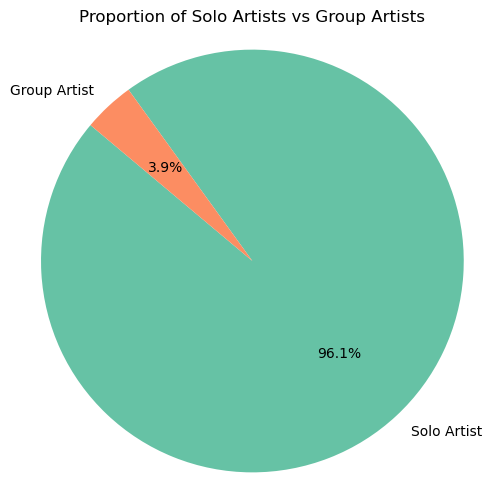

In [ ]:
# Assumption: The Groups column (groups_name) is either:
# Null or empty → likely a solo artist
# Contains one or more group names (as a JSON array or comma-separated string) → likely a band/group artist

artists_df = artists.withColumn(
    "groups_array", from_json("groups_name", ArrayType(StringType()))
)

artists_df = artists_df.withColumn(
    "artist_type",
    when(size(col("groups_array")) > 0, "Group Artist").otherwise("Solo Artist")
)

artist_type_counts = artists_df.groupBy("artist_type").count().toPandas()

import matplotlib.pyplot as plt

plt.figure(figsize=(6,6))
plt.pie(
    artist_type_counts["count"],
    labels=artist_type_counts["artist_type"],
    autopct="%1.1f%%",
    startangle=140,
    colors=["#66c2a5", "#fc8d62"]
)
plt.axis("equal")
plt.title("Proportion of Solo Artists vs Group Artists")
plt.show()

We wanted to understand the makeup of musical contributors: are most artists in the database solo performers, or are they members of bands and groups?
A quick glance at the pie chart reveals that a striking 96.1% of the artists are labeled as solo performers, while only 3.9% are classified as group artists.
To arrive at this distinction, we relied on the groups_name field — a column that lists any groups an artist is associated with. If this field was empty or null, we assumed the artist to be a solo performer. Conversely, if it contained one or more group names, we categorized the artist as part of a group or band.
However, this approach depends on the completeness of the data. The groups_name field may be null not because the artist is truly solo, but simply due to missing or incomplete information. As a result, there's a real possibility that our method overestimates the number of solo artists in the dataset.

We acknowledge this limitation and plan to continue refining our assumptions.

#### Summary

An analysis of the artist dataset reveals that 96.1% of artists are classified as solo performers, while only 3.9% are associated with groups. This classification is based on the presence or absence of entries in the groups_name field. However, this approach may overestimate solo artists due to potential missing or incomplete data.

### Masters Data

**1. Missing Values:**

In [ ]:
missing_masters = masters.select([
    _sum(col(c).isNull().cast("int")).alias(c + "_nulls")
    for c in masters.columns
])
missing_masters.show()

+------------------------+-----------------------+-------------------------+-------------------------+-------------------------+-------------------------+----------------------------------+-------------------------------+-----------------------------+---------------------------------+-----------------------+---------------------------------+--------------------------+--------------------------+-------------------------+------------------------------+------------------------+
|artists_artist_anv_nulls|artists_artist_id_nulls|artists_artist_join_nulls|artists_artist_name_nulls|master_genres_genre_nulls|master_styles_style_nulls|master_videos_video_duration_nulls|master_videos_video_embed_nulls|master_videos_video_src_nulls|masters_master_data_quality_nulls|masters_master_id_nulls|masters_master_main_release_nulls|masters_master_notes_nulls|masters_master_title_nulls|masters_master_year_nulls|videos_video_description_nulls|videos_video_title_nulls|
+------------------------+--------------

We observed substantial null entries in the Masters dataset and would consider this condition during our join operations to ensure data integrity.

**2. Proportion of Multi-Genre Master Releases Over Time:**

From the master dataset, we observed that some masters were labeled with multiple genres. Therefore, we explored the proportion of multi-genre masters and examined how it has changed over time by incorporating the release year.

In [ ]:
masters = masters.withColumn("genre_array", split(regexp_replace("master_genres_genre", r'[\[\]"]', ''), ",\\s*"))
masters = masters.withColumn("genre_count", size("genre_array"))
masters_clean = masters.filter("genre_count >= 0")
masters_clean = masters_clean.cache()

In [ ]:
masters_clean = masters_clean.filter("masters_master_year >= 1900")

In [ ]:
# Create columns: genre type to label single or multi genre
masters_clean = masters_clean.withColumn(
    "genre_type",
    when(col("genre_count") == 1, "Single").otherwise("Multi")
)

multi_per_year = masters_clean.filter(col("genre_type") == "Multi") \
    .groupBy("masters_master_year") \
    .agg(count("*").alias("multi_count"))

total_per_year = masters_clean.groupBy("masters_master_year") \
    .agg(count("*").alias("total"))

multi_genre_proportion = multi_per_year.join(total_per_year, on="masters_master_year") \
    .withColumn("proportion_multi", col("multi_count") / col("total")) \
    .orderBy("masters_master_year")

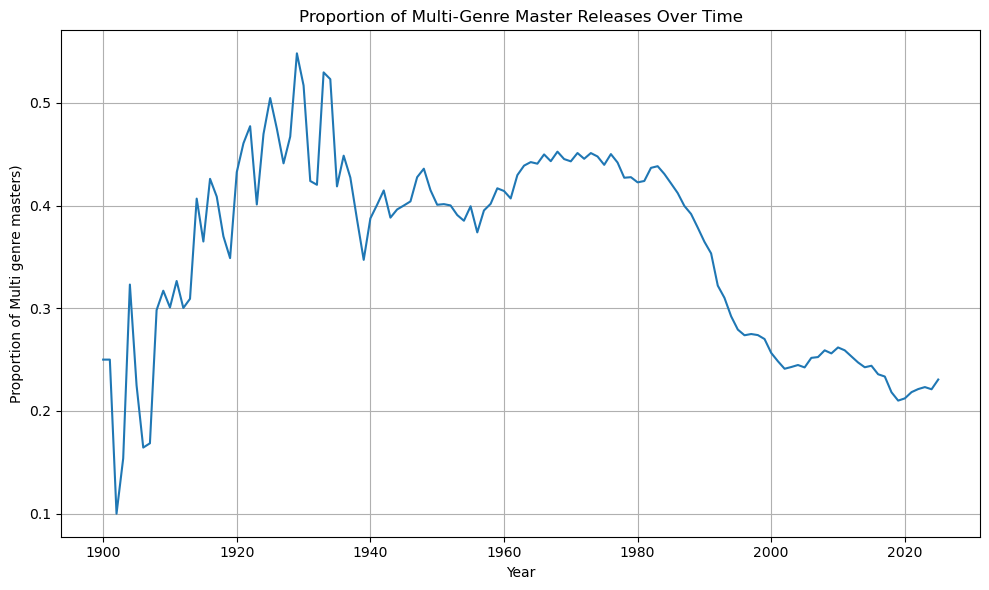

In [ ]:
multi_genre_perc = multi_genre_proportion.toPandas()

plt.figure(figsize=(10,6))
sns.lineplot(data=multi_genre_perc, x="masters_master_year", y="proportion_multi")
plt.title("Proportion of Multi-Genre Master Releases Over Time")
plt.xlabel("Year")
plt.ylabel("Proportion of Multi genre masters)")
plt.grid(True)
plt.tight_layout()
plt.show()

From the line plot above, we can observe that the proportion of multi-genre master releases was quite unstable during the early 1900s–1910s. This may be due to the small sample size during that period, and the trend might not be reliable.

Secondly, from the 1920s to the 1980s, the proportion remained relatively high, reaching around 40%, and even exceeding 50% in the 1930s.

Finally, after the 2000s, the proportion declined sharply to around 20%.

**3. Top 20 Artists by Number of Genres Released:**

In [ ]:
# explode to (artist, genre)
artist_genre = masters_clean.select(
    col("artists_artist_name").alias("artist"),
    explode("genre_array").alias("genre")
).dropna()

invalid_names = ["Unknown Artist", "No Artist", "Various"]
artist_genre_filtered = artist_genre.filter(~col("artist").isin(invalid_names))

# drop duplicates
artist_genre_distinct = artist_genre_filtered.dropDuplicates(["artist", "genre"])

# group by artist and count how many genres they have released in.
artist_genre_count = artist_genre_distinct.groupBy("artist") \
    .agg(countDistinct("genre").alias("num_genres")) \
    .orderBy(col("num_genres").desc())

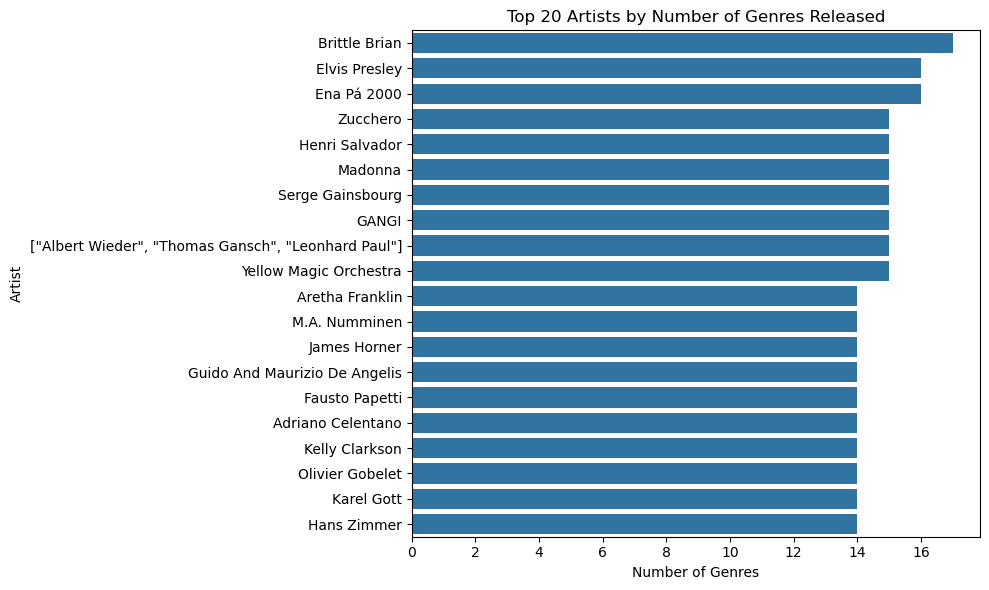

In [ ]:
artist_genre_count_pd20 = artist_genre_count.limit(20).toPandas()

plt.figure(figsize=(10, 6))
sns.barplot(data=artist_genre_count_pd20, y="artist", x="num_genres")
plt.title("Top 20 Artists by Number of Genres Released")
plt.xlabel("Number of Genres")
plt.ylabel("Artist")
plt.tight_layout()
plt.show()

From the table and the bar chart, we can see that several artists have works spanning more than 14 genres across their master releases.
However, this may be influenced by a few outlier masters that are tagged with an unusually large number of genres.
To address this, we decided to set a threshold for the minimum number of master releases per artist and re-examine the results.

**Setting a threshold for the minimum number of master releases per artist and re-examining the results**

In [ ]:
artist_master_count = masters_clean.groupBy("artists_artist_name") \
    .agg(countDistinct("masters_master_id").alias("num_masters"))

In [ ]:
artist_stats = artist_genre_count.join(
    artist_master_count,
    artist_genre_count["artist"] == artist_master_count["artists_artist_name"],
    how="inner"
).drop("artists_artist_name")

In [ ]:
artist_stats_filtered = artist_stats.filter(col("num_masters") >= 20)

# Look at the result after setting the minimum number of masters to 20
artist_stats_filtered = artist_stats_filtered.orderBy(col("num_genres").desc())

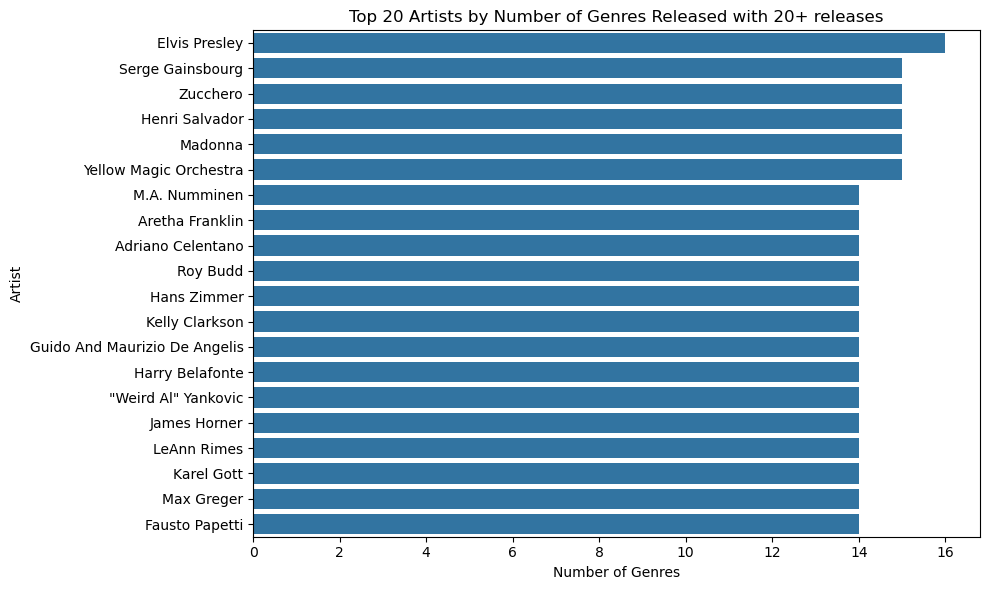

In [ ]:
artist_genre_count_pd20_filtered = artist_stats_filtered.limit(20).toPandas()

plt.figure(figsize=(10, 6))
sns.barplot(data=artist_genre_count_pd20_filtered, y="artist", x="num_genres")
plt.title("Top 20 Artists by Number of Genres Released with 20+ releases")
plt.xlabel("Number of Genres")
plt.ylabel("Artist")
plt.tight_layout()
plt.show()

The result shows that Elvis Presley has created works spanning the most genres, with a total of 16. Other top artists have also released works across up to 14 genres.

**4. Which Artists have the most Masters?**

In [ ]:
top_artists_by_id = masters.groupBy("artists_artist_id") \
    .agg(countDistinct("masters_master_id").alias("album_count")) \
    .orderBy(col("album_count").desc()) \
    .limit(20)


In [ ]:
top_artists_named = top_artists_by_id.join(
    artists_df.select("artist_id", "artist_name", "artist_realname"),
    top_artists_by_id["artists_artist_id"] == artists_df["artist_id"],
    "left"
).select(
    "artists_artist_id", "artist_name", "artist_realname", "album_count"
)


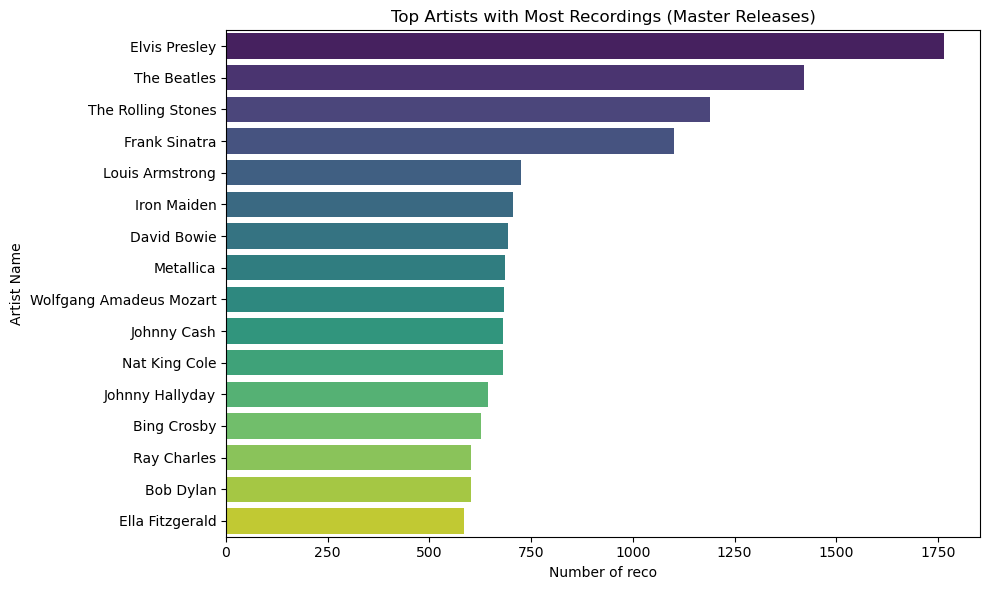

In [ ]:
top_artists_named_pd = top_artists_named.toPandas()

# Sort to make sure it's in descending order
top_artists_named_pd = top_artists_named_pd.sort_values(by="album_count", ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(
    y=top_artists_named_pd["artist_name"],
    x=top_artists_named_pd["album_count"],
    palette="viridis"
)

plt.title("Top Artists with Most Recordings (Master Releases)")
plt.xlabel("Number of reco")
plt.ylabel("Artist Name")
plt.tight_layout()
plt.show()

The chart shows that the top five artists — Elvis Presley, The Beatles, The Rolling Stones, Frank Sinatra, and Louis Armstrong — are iconic figures whose decades-spanning careers and lasting popularity have resulted in extensive documentation and numerous releases.

The list includes both solo performers (e.g., Frank Sinatra, Johnny Cash, Ella Fitzgerald) and bands (e.g., The Beatles, Metallica, Iron Maiden), and covers a wide range of genres including rock, jazz, classical, metal, and pop — suggesting that prolific output transcends musical style.

Overall, the chart reflects how musical legacy and influence often correlate with a high volume of master recordings, especially for artists with long or posthumously extended careers.

**5. Which are the top artists with most recordings before and after the year 2000?**

In [ ]:
# Add "release_era"
masters_with_era = masters.withColumn(
    "release_era",
    when(col("masters_master_year") < 2000, "Before 2000")
    .when(col("masters_master_year") >= 2000, "2000 and After")
)

era_counts = masters_with_era.groupBy("artists_artist_id", "release_era") \
    .count() \
    .filter(col("release_era").isNotNull())

era_named = era_counts.join(
    artists_df.select("artist_id", "artist_name"),
    era_counts["artists_artist_id"] == artists_df["artist_id"],
    "left"
).select("artist_name", "release_era", "count")

era_named_pd = era_named.toPandas()

before_2000_top = era_named_pd[era_named_pd["release_era"] == "Before 2000"] \
    .sort_values("count", ascending=False).head(20)

after_2000_top = era_named_pd[era_named_pd["release_era"] == "2000 and After"] \
    .sort_values("count", ascending=False).head(20)

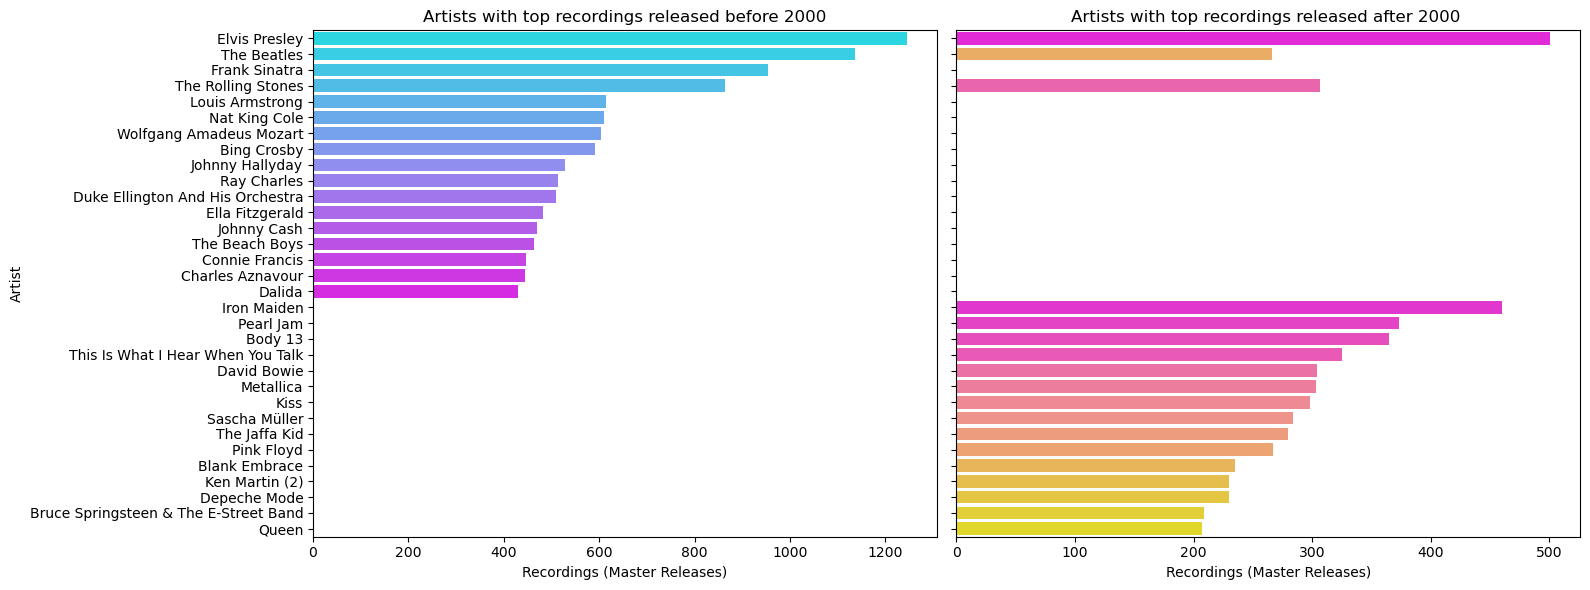

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6), sharey=True)

# Before 2000
sns.barplot(
    data=before_2000_top,
    x="count",
    y="artist_name",
    ax=axes[0],
    palette="cool"
)
axes[0].set_title("Artists with top recordings released before 2000")
axes[0].set_xlabel("Recordings (Master Releases)")
axes[0].set_ylabel("Artist")

# After 2000
sns.barplot(
    data=after_2000_top,
    x="count",
    y="artist_name",
    ax=axes[1],
    palette="spring"
)
axes[1].set_title("Artists with top recordings released after 2000 ")
axes[1].set_xlabel("Recordings (Master Releases)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.show()

To explore how music trends and artist popularity have shifted over time, we compared data from before and after the year 2000 — marking 25 years of recent music evolution.

Before 2000, the landscape was dominated by legendary figures like Elvis Presley, The Beatles, and Frank Sinatra, whose long careers and global influence helped define genres like rock, jazz, and classical. Their high volume of releases reflects both enduring popularity and traditional production models.

After 2000, the artists in this list showcases a shift toward heavy metal, electronic, indie, and underground genres. These artists tend to have smaller but highly active catalogs (typically under 500 master releases), suggesting a move toward digital-first, independent distribution and fragmented listening audiences.

Overall, this comparison reflects the evolution of the music industry—from a few dominant global stars to a more decentralized, digital-driven landscape offering greater opportunities for niche and independent artists.

#### Summary

**Genres Evaluation**

From our analysis of the masters, we observed interesting trends in the proportion of masters with multiple genres from the 1900s till date. It was seen to be highly varied in the early 20th century, potentially due to a smaller sample size, after which the proportion remained relatively high until the 1980s, suggesting the popularity of cross-genre experimentation and fusion during this period. During and after the 80s, a sharp decline from over 40% to around 20% is observed., possibly influenced by commercial patterns, and artists adhering to trends on digital music platforms that favor clear genre separation. The decline in multi-genre releases post-2000s may reflect the rise of streaming platforms, where music discovery and playlist curation rely on well-defined genre labels, potentially discouraging ambiguous categorization.

**Artist and Genres**

We also explored the most versatile artists, whose work spanned the most genres across their masters. There were multiple artists with works spanning more than 14 genres, but this was influenced by a small number of outlier masters tagged with an unusually large number of genres. Adjusting for a threshold of minimum number of master releases per artist, we observed that the works of Elvis Presley spanned the most genres (16 in total), followed by Serge Gainsbourg, Zucchero, Henri Salvador, Madonna and Yellow Magic Orchestra (15 each). The presence of international artists in this list suggests that genre fluidity may also be driven by cultural diversity and regional music traditions.

Additionally, an analysis of artists associated with released recordings shows a strong correlation between artist popularity and the volume of master recordings. This suggests that an artist’s musical legacy can extend well beyond their active years, including posthumous releases. The data also reflects a shift in music preferences over the past 25 years - moving from dominant genres like jazz and rock toward a more diverse range that includes heavy metal, electronic, and underground styles, highlighting the evolving landscape of musical expression.

### Labels Data

**1. The Sublabel Counts:**

In [ ]:
labels.select("sublabels_label").distinct().count()

118411

**2. Number of Sublabels in every Parent Label:**

In [ ]:
labels.groupBy("label_parentLabel").agg(F.count("sublabels_label").alias("num_sublabels")).orderBy(desc("num_sublabels")).show()

+--------------------+-------------+
|   label_parentLabel|num_sublabels|
+--------------------+-------------+
|                NULL|       106362|
|Universal Music G...|          114|
|  Warner Music Group|           53|
|Sony Music Entert...|           53|
|            PolyGram|           49|
|Sony Music Entert...|           39|
|                 BMG|           34|
|Warner Music Inte...|           29|
| Concord Music Group|           28|
|           EMI Music|           24|
|      EMI Group Ltd.|           23|
|Warner Music UK Ltd.|           22|
|            CBS Inc.|           22|
|            Atlantic|           22|
|EMI Music Publish...|           21|
|     Reader's Digest|           19|
|Universal Music GmbH|           19|
|Universal Music P...|           18|
|Cherry Red Record...|           18|
|            EMI Ltd.|           18|
+--------------------+-------------+
only showing top 20 rows



According to the table shown above, there are a lot of parentlabel that are Null contained in the label dataset. So the first line of the table is useless. Noticing that there is a problem that there might be some parent labels that are the same but calling in different names.

The following graph is the barplot of top 5 labels after removing the Null parent labels.

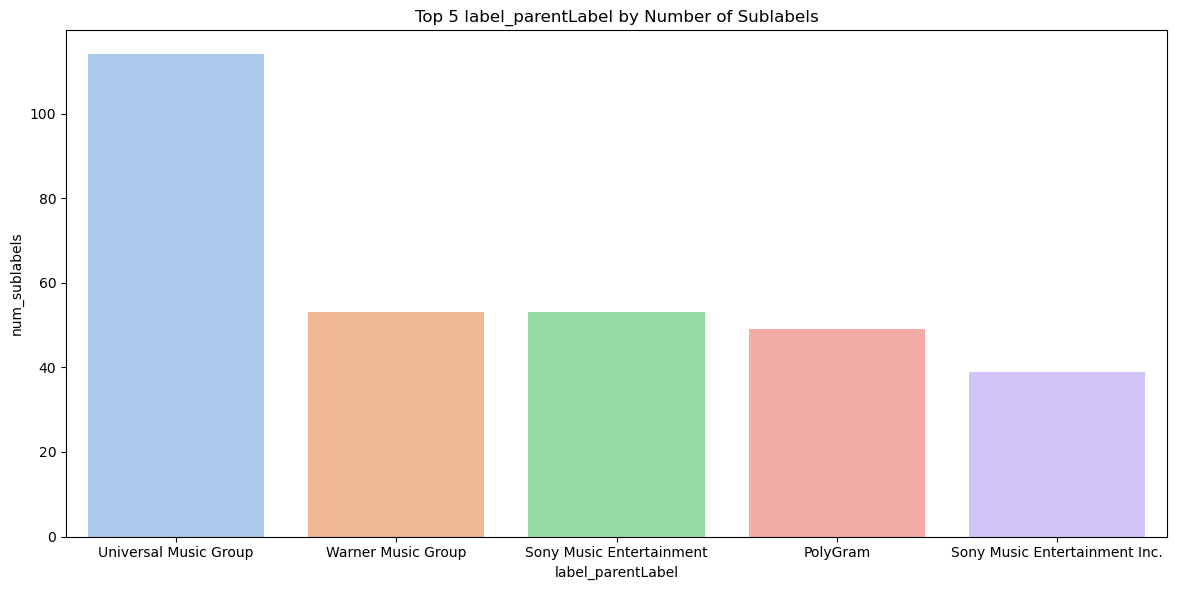

In [ ]:
filtered_labels = labels.filter(col("label_parentLabel").isNotNull() & col("sublabels_label").isNotNull())

agg_labels = filtered_labels.groupBy("label_parentLabel") \
    .agg(count("sublabels_label").alias("num_sublabels")) \
    .orderBy(desc("num_sublabels"))

pandas_labels = agg_labels.toPandas()
pandas_labels = pandas_labels.head(5)

plt.figure(figsize=(12, 6))
sns.barplot(data=pandas_labels, x="label_parentLabel", y="num_sublabels", palette="pastel")

plt.xticks()
plt.xlabel("label_parentLabel")
plt.ylabel("num_sublabels")
plt.title("Top 5 label_parentLabel by Number of Sublabels")
plt.tight_layout()
plt.show()

According to the graph shown above, the Universal Music Group has the most sublabels, and is the only company with more than 100 sublabels. The following are warner Music Group (53), Sony (53), and PolyGram (49). This result is reasonable because UMG is the head of the music industry, covering more music labels and genres.

**3. Missing Value Count:**

In [ ]:
missing_labels = labels.select([
    _sum(col(c).isNull().cast("int")).alias(c + "_nulls")
    for c in labels.columns
])
missing_labels.show()

+---------------------+------------------------+--------------+-----------+-----------------------+------------------------+--------------+----------------+-----------------------+--------------------------+-------------------+
|sublabels_label_nulls|sublabels_label_id_nulls|urls_url_nulls|label_nulls|label_contactinfo_nulls|label_data_quality_nulls|label_id_nulls|label_name_nulls|label_parentLabel_nulls|label_parentLabel_id_nulls|label_profile_nulls|
+---------------------+------------------------+--------------+-----------+-----------------------+------------------------+--------------+----------------+-----------------------+--------------------------+-------------------+
|              2381440|                 2381248|       2316088|    2319228|                2351005|                  317963|        120739|          306136|                2374613|                   2327335|            1846089|
+---------------------+------------------------+--------------+-----------+-------------

**4. Label data_quality Proportion:**

In [ ]:
labels.groupBy("label_name", "label_data_quality").count().orderBy("label_name", desc("count")).show()

+--------------------+-------------------+------+
|          label_name| label_data_quality| count|
+--------------------+-------------------+------+
|                NULL|               NULL|306135|
|                NULL|         Needs Vote|     1|
| Chansons Italien...|         Needs Vote|     1|
|     Chansons-Vogue |         Needs Vote|     1|
| La Boîte À Musique |            Correct|     1|
| The Live House M...|Needs Major Changes|     1|
|                   !|            Correct|     1|
|     ! Graphics Bina|Needs Major Changes|     1|
|! Selur Sreleets ...|Needs Major Changes|     1|
|   ! f a n c u l o !|         Needs Vote|     1|
|!! Attention Records|Needs Major Changes|     1|
|                 !!!|            Correct|     1|
|!!!Fuck Off!!! Re...|Needs Major Changes|     1|
|            !!444!!!|               NULL|     1|
|          !!Attack!!|         Needs Vote|     1|
|           !!Concept|Needs Major Changes|     1|
|!!HatefullUndergr...|Needs Major Changes|     1|


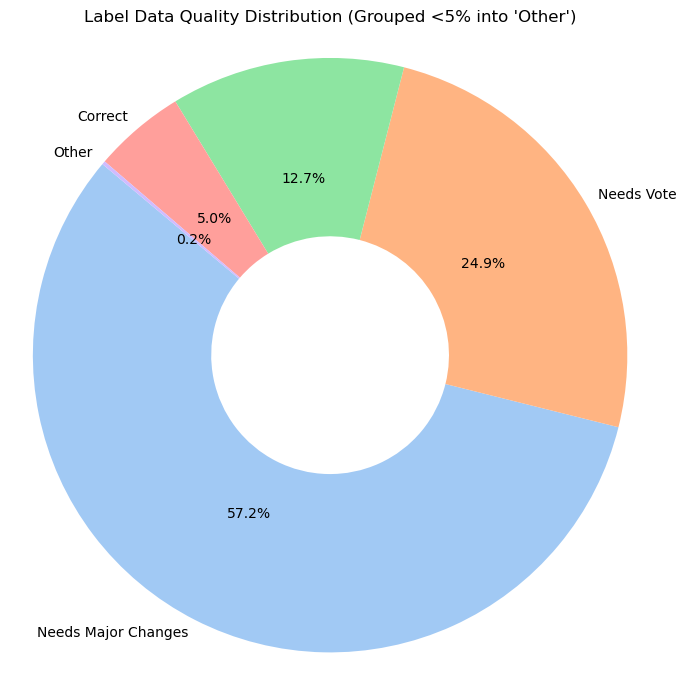

In [ ]:
dq_labels = labels.groupBy("label_data_quality").count().orderBy(desc("count"))
dq_pd = dq_labels.toPandas()

dq_pd["percentage"] = dq_pd["count"] / dq_pd["count"].sum()

main_labels = dq_pd[dq_pd["percentage"] >= 0.03].copy()
other_labels = dq_pd[dq_pd["percentage"] < 0.03].copy()

other_row = pd.DataFrame({
    "label_data_quality": ["Other"],
    "count": [other_labels["count"].sum()],
    "percentage": [other_labels["percentage"].sum()]
})

final_labels = pd.concat([main_labels, other_row], ignore_index=True)

colors = sns.color_palette("pastel")[0:len(final_labels)]

plt.figure(figsize=(7, 7))
plt.pie(final_labels["count"],
        labels=final_labels["label_data_quality"],
        autopct="%1.1f%%",
        startangle=140,
        colors=colors,
        labeldistance=1.05,
        wedgeprops=dict(width=0.6))
plt.title("Label Data Quality Distribution (Grouped <5% into 'Other')")
plt.axis("equal")
plt.tight_layout()
plt.show()

According to the pie chart above, there are about 57.2% of the data needs major change, becoming the majority of the proportion.

**5. label_profile Length Distribution:**

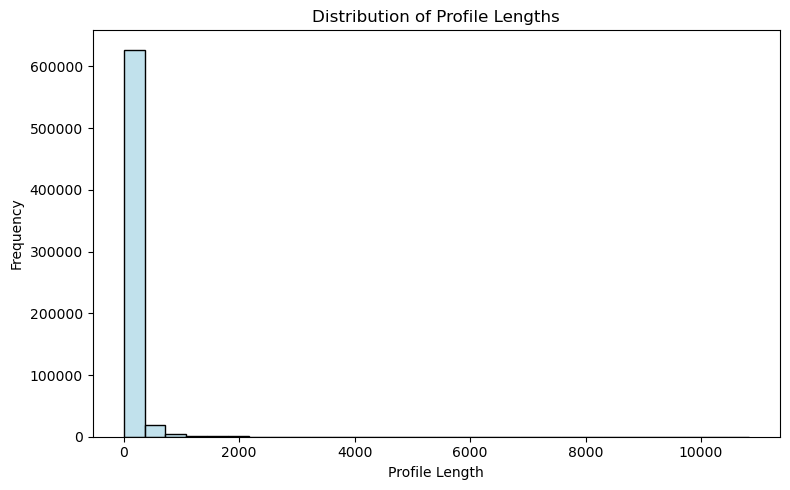

In [ ]:
length_labels = labels.select(length("label_profile").alias("profile_len")).dropna()
length_pd = length_labels.toPandas()

plt.figure(figsize=(8, 5))
sns.histplot(data=length_pd, x="profile_len", bins=30, color="lightblue", edgecolor="black")
plt.title("Distribution of Profile Lengths")
plt.xlabel("Profile Length")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

The graph above indicates there are outliers for the profile lengths. So we created the normal range histogram and outlier histogram.

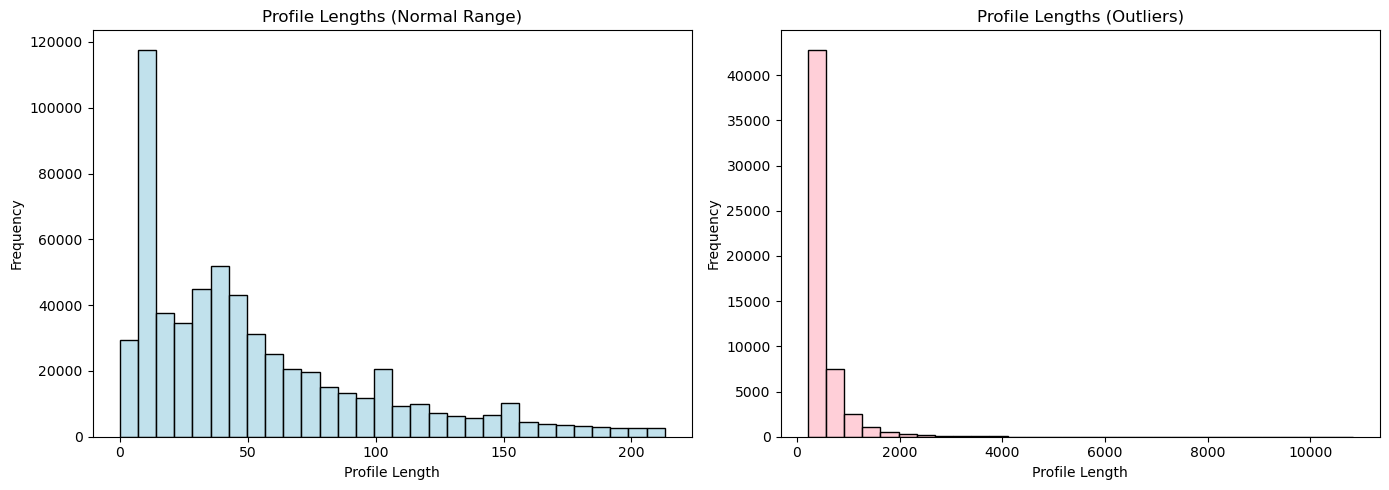

In [ ]:
Q1 = length_pd["profile_len"].quantile(0.25)
Q3 = length_pd["profile_len"].quantile(0.75)
IQR = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR

normal_data = length_pd[length_pd["profile_len"] <= upper_bound]
outlier_data = length_pd[length_pd["profile_len"] > upper_bound]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.histplot(data=normal_data, x="profile_len", bins=30, color="lightblue", edgecolor="black", ax=axes[0])
axes[0].set_title("Profile Lengths (Normal Range)")
axes[0].set_xlabel("Profile Length")
axes[0].set_ylabel("Frequency")

sns.histplot(data=outlier_data, x="profile_len", bins=30, color="pink", edgecolor="black", ax=axes[1])
axes[1].set_title("Profile Lengths (Outliers)")
axes[1].set_xlabel("Profile Length")
axes[1].set_ylabel("Frequency")

plt.tight_layout()
plt.show()

According to the normal range graph, the distribution is positively skewed, with majority of the profiles fall in length between 0 - 50 words. Also for the outlier one, it also has the positive skewed curve.

#### Summary

There are 11 columns contained in the labels dataset. with each columns, at least 120739 null values are held in the dataset. In specific, there is a unique relationship between the labels - parentlabel, label, and sublabel. This is the Hierarchical Label relationship contained in the dataset. After exploring, we found that there are some labels being the parentlabels by themselves, some of the labels don't contain sublabels, and some of the parentlabels containing multiple labels. All the relationships between labels are many to many with 0 inlcuded. In addition, for the "label_data_quality" column, we did the pie chart and foudn that there are about 52% of the observations has the quality of major changes, which means the quality of the label data is not thoroughly great to use. Finally, we checked the label_profile length. According to the results, the label_profile_length are widely distributed and extremely positively skewed, with a certain proportion of outliers. In the normal range, the profile length is also positively skewed and the mode fail in the 0-50 range, which means the majority of the label_profile are not long. However, when comes to the outlier graph, the range still goes to 10,000, which is a extreme case.

## Genre Classification Machine Learning Model

We will now be constructing a supervised machine learning model, that classifies each release as a specific genre. But before this, we must complete some data preprocessing steps to ensure that we have the right variables with the right data for the model.

### Preprocessing

In [ ]:
# selecting relevant columns from artists
selected_artists = artists.select("artist_id", 'artist_profile')

In [ ]:
# left join releases and artists
joined_data = releases.join(selected_artists, releases['artists_artist_id'] == selected_artists['artist_id'], how='left')

We will now shift our focus to releases_genres_genre, which we have observed to include anywhere between 1 and 17 genres for each release. For our model, we will be extracting the first genre for multi-genre releases under the assumption that it is the most relevant among the multiple genres. We will then focus on the top 10 genres by popularity.

In [ ]:
# total number of genres/genre combinations before reduction
joined_data.select('release_genres_genre').distinct().count()

6683

In [ ]:
joined_data.groupBy('release_genres_genre') \
    .agg(count('*').alias('count')) \
    .orderBy('count', ascending=False) \
    .show()

+--------------------+-------+
|release_genres_genre|  count|
+--------------------+-------+
|                Rock|3612441|
|          Electronic|3177312|
|                 Pop|1217296|
|Folk, World, & Co...|1210459|
|                NULL| 857330|
|           Classical| 807526|
|                Jazz| 673794|
|     ["Rock", "Pop"]| 643897|
|             Hip Hop| 536031|
|         Funk / Soul| 476304|
|               Latin| 319832|
|              Reggae| 288274|
|["Electronic", "R...| 286652|
|["Electronic", "P...| 244677|
|["Pop", "Folk, Wo...| 228047|
|["Rock", "Folk, W...| 156040|
|           Non-Music| 151086|
|     ["Jazz", "Pop"]| 144379|
|      Stage & Screen| 125594|
|               Blues|  98077|
+--------------------+-------+
only showing top 20 rows



In [ ]:
# removing [, ] and " in the release_genres_genre column
joined_data = joined_data.withColumn("release_genres_genre", regexp_replace("release_genres_genre", "[\\[\\]\"]", ""))

# assuming that the first genre is the most relevant, we are extracting the first genre from the list of genres
joined_data = joined_data.withColumn("release_genres_genre", substring_index("release_genres_genre", ",", 1))

# final number of genres
joined_data.select('release_genres_genre').distinct().count()

17

In [ ]:
joined_data = joined_data.where(col("release_genres_genre").isNotNull())

joined_data.groupBy('release_genres_genre') \
    .agg(count('*').alias('count')) \
    .orderBy('count', ascending=False) \
    .show()

+--------------------+-------+
|release_genres_genre|  count|
+--------------------+-------+
|                Rock|4876732|
|          Electronic|4438668|
|                 Pop|1602899|
|                Folk|1244793|
|                Jazz|1242974|
|           Classical| 893068|
|             Hip Hop| 677642|
|         Funk / Soul| 620750|
|               Latin| 553605|
|              Reggae| 320730|
|           Non-Music| 243452|
|               Blues| 125827|
|      Stage & Screen| 125595|
|          Children's|  75416|
|    Brass & Military|  38722|
|                   1|     18|
+--------------------+-------+



In [ ]:
# extracting the records with genres in the top 10 genres by count
top_genres = joined_data.groupBy("release_genres_genre") \
    .agg(count("*").alias("count")) \
    .orderBy("count", ascending=False) \
    .limit(10)

top_genres_list = [row["release_genres_genre"] for row in top_genres.collect()]

filtered_data = joined_data.filter(col("release_genres_genre").isin(top_genres_list))

filtered_data.groupBy('release_genres_genre') \
    .agg(count('*').alias('count')) \
    .orderBy('count', ascending=False) \
    .show()

+--------------------+-------+
|release_genres_genre|  count|
+--------------------+-------+
|                Rock|4876732|
|          Electronic|4438668|
|                 Pop|1602899|
|                Folk|1244793|
|                Jazz|1242974|
|           Classical| 893068|
|             Hip Hop| 677642|
|         Funk / Soul| 620750|
|               Latin| 553605|
|              Reggae| 320730|
+--------------------+-------+



In [ ]:
filtered_data.count()

16471861

The releases_release_released column includes the date the release was released. However, the field interchangeably uses Year or Date to specify the same. For uniformity, we will be extracting the Year from the Date values.

In [ ]:
# Extract year using regex: four digits at the beginning of the string
filtered_data = filtered_data.withColumn(
    "release_year",
    regexp_extract(col("releases_release_released"), r"^(\d{4})", 1)
)

The companies_company_entity_type and companies_company_entity_type_array include information on the companies involved with the release and the nature of their involvement. This could range from music production, vinyl/CD production, distribution, etc. In order to narrow this down, we will be focusing on the companies involved in the Music Production and Publishing of the release in question.

The correspondent company entity type ids for "Published By" and "Produced For" are "21" and "37".

In [ ]:
# First, I transform these two columns from string to array
filtered_data = filtered_data.withColumn("companies_company_entity_type_array", from_json("companies_company_entity_type", ArrayType(StringType()))) \
    .withColumn("companies_company_id_array", from_json("companies_company_id", ArrayType(StringType())))

In [ ]:
# After that, for these two columns, I extracted the first corresponding company ID and stored them into new columns.
# If a release did not include a company of type "Published By" or "Produced For", the corresponding field was set to NULL

# Capture the first Company for "Published By"(type="21") and then create a column to store the company id
filtered_data = filtered_data.withColumn(
    "published_by_id",
    expr("""
        element_at(
            filter(
                zip_with(companies_company_entity_type_array, companies_company_id_array,
                    (t, id) -> IF(t = '21', id, NULL)
                ),
                x -> x IS NOT NULL
            ),
        1)
    """)
)

# Capture the first Company for "Produced For"(type="37") and then create a column to store the company id
filtered_data = filtered_data.withColumn(
    "produced_for_id",
    expr("""
        element_at(
            filter(
                zip_with(companies_company_entity_type_array, companies_company_id_array,
                    (t, id) -> IF(t = '37', id, NULL)
                ),
                x -> x IS NOT NULL
            ),
        1)
    """)
)

# Cache
filtered_data.cache()

DataFrame[artists_artist_id: string, companies_company_entity_type: string, companies_company_id: string, extraartists_artist_id: string, extraartists_artist_role: string, release_formats_format_name: string, release_genres_genre: string, release_styles_style: string, releases_release_country: string, releases_release_master_id: string, releases_release_released: string, releases_release_status: string, artist_id: string, artist_profile: string, release_year: string, companies_company_entity_type_array: array<string>, companies_company_id_array: array<string>, published_by_id: string, produced_for_id: string]

In [ ]:
# See how many rows are not nulls for these two columns
filtered_data.filter(
    (filtered_data["published_by_id"].isNotNull()) |
    (filtered_data["produced_for_id"].isNotNull())
).count()

1287854

In [ ]:
filtered_data = filtered_data.drop("extraartists_artist_id", "extraartists_artist_role", "releases_release_master_id", "artist_id")

The releases_styles_style column includes subcategories that can be used to describe the style of music involved in the record. As these are subcategories, they tend to have multiple different styles that can describe a release. In order to properly assess their influence on the genre, we will be extracting the most relevant style from the list. This can be expanded in the future, where more styles are extracted in order to potentially improve the accuracy of the model.

In [ ]:
# Additional cleaning for the "release_styles_style" column:
# Assuming this column stores a list (e.g. "['Techno','Deep House']") as a string, we:
#   Convert to lower-case and trim whitespace.
#   Remove brackets and extra quotes.
#   Split the string into an array based on comma as a delimiter.

filtered_data = filtered_data.withColumn("rowId", monotonically_increasing_id())
subgenre_data = filtered_data
subgenre_data = subgenre_data.withColumn("cleaned_release_styles",
                                F.lower(F.trim(F.col("release_styles_style"))))
# Remove square brackets and quotes
subgenre_data = subgenre_data.withColumn("cleaned_release_styles",
                                F.regexp_replace("cleaned_release_styles", r'[\[\]"]', ''))
# Split by comma (allowing for spaces around the comma)
subgenre_data = subgenre_data.withColumn("styles_array",
                                F.split(F.regexp_replace("cleaned_release_styles", r'\s*,\s*', ','), ","))


In [ ]:
#  Frequency Analysis: Count how many times each style appears.
#    This helps identify which sub-genres are most common.
subgenres_freq = subgenre_data.select(F.explode("styles_array").alias("style")) \
                      .groupBy("style") \
                      .count() \
                      .orderBy(F.desc("count"))

In [ ]:
# Use CountVectorizer and TF-IDF for further text mining.
#    These steps help quantify the importance of each sub-genre per release.
# but need to filter out rows with null or empthy

# Filter out rows with null or empty styles_array
releases_non_null = subgenre_data.filter(
    F.col("styles_array").isNotNull() & (F.size("styles_array") > 0)
)

# Apply CountVectorizer on the filtered data
cv = CountVectorizer(inputCol="styles_array", outputCol="rawFeatures", vocabSize=500, minDF=1)
cv_model = cv.fit(releases_non_null)
releases_cv = cv_model.transform(releases_non_null)

# Apply TF-IDF transformation
idf = IDF(inputCol="rawFeatures", outputCol="features")
idf_model = idf.fit(releases_cv)
releases_tfidf = idf_model.transform(releases_cv)

releases_tfidf.select("styles_array", "features").show(5, truncate=False)

+---------------------+------------------------------------------------------+
|styles_array         |features                                              |
+---------------------+------------------------------------------------------+
|[trance]             |(500,[20],[3.9573672025284052])                       |
|[trance]             |(500,[20],[3.9573672025284052])                       |
|[trance]             |(500,[20],[3.9573672025284052])                       |
|[uk garage, bassline]|(500,[145,340],[5.921830702907935,7.8026403657503085])|
|[uk garage]          |(500,[145],[5.921830702907935])                       |
+---------------------+------------------------------------------------------+
only showing top 5 rows



In [ ]:
# Get the vocabulary generated by CountVectorizer
vocab = cv_model.vocabulary

def rep_subgenre(features):
    """
    Given a TF-IDF vector (a SparseVector), return the sub-genre token with the highest weight.
    If the vector is null or contains no nonzero elements, return None.
    """
    if features is None or not isinstance(features, SparseVector):
        return None
    if features.numNonzeros() == 0:
        return None
    max_value = -1.0
    best_index = -1
    for idx, value in zip(features.indices, features.values):
        if value > max_value:
            max_value = value
            best_index = idx
    if best_index >= 0:
        return vocab[best_index]
    return None

rep_subgenre_udf = udf(rep_subgenre, StringType())

releases_final = releases_tfidf.withColumn("representative_subgenre", rep_subgenre_udf("features"))

releases_final.select("styles_array", "features", "representative_subgenre").show(5, truncate=False)
releases_final = releases_final.select('rowId', 'representative_subgenre')

+---------------------+------------------------------------------------------+-----------------------+
|styles_array         |features                                              |representative_subgenre|
+---------------------+------------------------------------------------------+-----------------------+
|[trance]             |(500,[20],[3.9573672025284052])                       |trance                 |
|[trance]             |(500,[20],[3.9573672025284052])                       |trance                 |
|[trance]             |(500,[20],[3.9573672025284052])                       |trance                 |
|[uk garage, bassline]|(500,[145,340],[5.921830702907935,7.8026403657503085])|bassline               |
|[uk garage]          |(500,[145],[5.921830702907935])                       |uk garage              |
+---------------------+------------------------------------------------------+-----------------------+
only showing top 5 rows



In [ ]:
data_try = filtered_data.join(releases_final, on = "rowId", how = 'left')

We will now utlize StringIndexer to convert categorical string columns to numerical indices, in order to include them in our Machine Learning model.

In [ ]:
columns_to_encode = ["release_formats_format_name","releases_release_country", "releases_release_status", 'release_genres_genre', "representative_subgenre"]

indexers = [
    StringIndexer(inputCol=col, outputCol=f"{col}_indexer", handleInvalid="keep")
    for col in columns_to_encode
]

pipeline = Pipeline(stages=indexers)

Label_model = pipeline.fit(data_try)
filtered_data = Label_model.transform(data_try)

In [ ]:
final_data = filtered_data.select(["artists_artist_id", "release_formats_format_name_indexer","release_genres_genre_indexer", "representative_subgenre_indexer", "release_year", "releases_release_status_indexer",
 "artist_profile","published_by_id", "produced_for_id"])

In [ ]:
final_data.show(5)

+-----------------+-----------------------------------+----------------------------+-------------------------------+------------+-------------------------------+--------------------+---------------+---------------+
|artists_artist_id|release_formats_format_name_indexer|release_genres_genre_indexer|representative_subgenre_indexer|release_year|releases_release_status_indexer|      artist_profile|published_by_id|produced_for_id|
+-----------------+-----------------------------------+----------------------------+-------------------------------+------------+-------------------------------+--------------------+---------------+---------------+
|          1016816|                                0.0|                         3.0|                          251.0|        NULL|                            0.0|Lucília Nunes Asc...|           NULL|           NULL|
|         10208749|                                0.0|                         0.0|                          500.0|        NULL|           

In [ ]:
final_data.write.mode("overwrite").option("header", True).csv("gs://group5-qst843-spring25-dataproc/data/final_data.csv")

In [ ]:
final_data = spark.read \
    .option("header", True) \
    .option("inferSchema", True) \
    .csv("gs://group5-qst843-spring25-dataproc/data/final_data.csv")

###  Model Construction

**Split Data**

In [ ]:
subset_data = final_data.dropna()
subset_data = subset_data.drop('artist_profile')

In [ ]:
subset_data.printSchema()

root
 |-- artists_artist_id: string (nullable = true)
 |-- release_formats_format_name_indexer: string (nullable = true)
 |-- release_genres_genre_indexer: string (nullable = true)
 |-- representative_subgenre_indexer: string (nullable = true)
 |-- release_year: string (nullable = true)
 |-- releases_release_status_indexer: string (nullable = true)
 |-- published_by_id: string (nullable = true)
 |-- produced_for_id: string (nullable = true)



In [ ]:
# Identify string columns
string_cols = [field.name for field in subset_data.schema.fields if isinstance(field.dataType, StringType)]

# Cast them to double
for col_name in string_cols:
    subset_data = subset_data.withColumn(col_name, col(col_name).cast("double"))

subset_data.printSchema()

root
 |-- artists_artist_id: double (nullable = true)
 |-- release_formats_format_name_indexer: double (nullable = true)
 |-- release_genres_genre_indexer: double (nullable = true)
 |-- representative_subgenre_indexer: double (nullable = true)
 |-- release_year: double (nullable = true)
 |-- releases_release_status_indexer: double (nullable = true)
 |-- published_by_id: double (nullable = true)
 |-- produced_for_id: double (nullable = true)



In [ ]:
train_data, test_data = subset_data.randomSplit([0.7, 0.3], seed=42)

**Standardize Data**

In [ ]:
feature_cols = ["artists_artist_id", "release_formats_format_name_indexer", "representative_subgenre_indexer", "release_year", "releases_release_status_indexer","published_by_id", "produced_for_id"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
train_data = assembler.transform(train_data)
test_data  = assembler.transform(test_data)

In [ ]:
scaler = StandardScaler(
    inputCol="features", outputCol="scaled_features", withMean=True, withStd=True
)

scalerModel = scaler.fit(train_data)
scaled_train = scalerModel.transform(train_data)
scaled_test = scalerModel.transform(test_data)

Now that we have completed the data preprocessing, we can build our machine learning models. We will use Logistic Regressor as a baseline model to compare our other models with, and we assume that improvements can be made by employing other models like SVM or Random Forest, and completing hyperparameter tuning within them.

#### Logistic Regressor

In [ ]:
lr = LogisticRegression(
    featuresCol="scaled_features",
    labelCol="release_genres_genre_indexer",
    family="multinomial",
    maxIter=20,
    regParam=0.1,
    elasticNetParam=0.0
)


lr_model = lr.fit(scaled_train)


train_predictions = lr_model.transform(scaled_train)
test_predictions  = lr_model.transform(scaled_test)


evaluator = MulticlassClassificationEvaluator(
    labelCol="release_genres_genre_indexer",
    predictionCol="prediction",
    metricName="accuracy"
)

train_acc = evaluator.evaluate(train_predictions)
test_acc  = evaluator.evaluate(test_predictions)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test  Accuracy: {test_acc:.4f}")

Train Accuracy: 0.4615
Test  Accuracy: 0.4576


Our baseline Logistic Regressor works decently well, with an accuracy of 0.458 on the test set, which was better than our initial expectations, considering we're looking at 10 categories.

Let us now look at how we can improve on this accuracy.

#### Support Vector Machine Classifier

In [ ]:
svm = LinearSVC(
    featuresCol="features",
    labelCol="release_genres_genre_indexer",
    maxIter=10,
    regParam=0.1
)


ovr = OneVsRest(
    classifier=svm,
    labelCol="release_genres_genre_indexer",
    featuresCol="features",
    predictionCol="prediction"
)


ovrModel = ovr.fit(scaled_train)


train_preds = ovrModel.transform(scaled_train)
test_preds  = ovrModel.transform(scaled_test)


evaluator = MulticlassClassificationEvaluator(
    labelCol="release_genres_genre_indexer",
    predictionCol="prediction",
    metricName="accuracy"
)

train_acc = evaluator.evaluate(train_preds)
test_acc  = evaluator.evaluate(test_preds)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test  Accuracy: {test_acc:.4f}")


Train Accuracy: 0.4362
Test  Accuracy: 0.4354


Our SVM model seems to perform worse than the Logistic Regression model, with a test accuracy of just 0.435.

We will now explore Random Forest Classifier, in an attempt to improve our predictions.

#### Random Forest Classfier

In [ ]:
rf = RandomForestClassifier(
    featuresCol="scaled_features",
    labelCol="release_genres_genre_indexer",
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction",
    numTrees=20,
    maxDepth=5,
    seed=42
)


rf_model = rf.fit(scaled_train)


train_preds = rf_model.transform(scaled_train)
test_preds  = rf_model.transform(scaled_test)


evaluator = MulticlassClassificationEvaluator(
    labelCol="release_genres_genre_indexer",
    predictionCol="prediction",
    metricName="accuracy"
)


train_acc = evaluator.evaluate(train_preds)
test_acc  = evaluator.evaluate(test_preds)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test  Accuracy: {test_acc:.4f}")


Train Accuracy: 0.5903
Test  Accuracy: 0.5850


We immediately see an improvement with the Random Forest Classifier, with an accuracy of 0.585 on the test set, more than what we've achieved with Logistic Regression or SVM.

We will now try to include text fields, and see if that helps the predictions.

### Text Mining

The artist_profile column includes a decription of the artist, with information on their background and influences. We assume this will give us some valuable insight into the genre of music they tend to create. In order to utilise this text data, we will be tokenizing and vectorizing the same.

In [ ]:
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, when
from pyspark.ml import Pipeline
from pyspark.ml.feature import (
    Tokenizer,
    StopWordsRemover,
    HashingTF,
    IDF
)

text_mining = final_data


text_mining = text_mining.withColumn(
    "artist_profile_clean",
    when(col("artist_profile").isNull(), "")
    .when(col("artist_profile").rlike(r"^\[b\]DO NOT USE\.\[/b\]$"), "")
    .otherwise(col("artist_profile"))
)

# Tokenize
tokenizer = Tokenizer(
    inputCol="artist_profile_clean",
    outputCol="tokens"
)

# Stopward
remover = StopWordsRemover(
    inputCol="tokens",
    outputCol="filtered_tokens"
)

# TF-IDF
hashingTF = HashingTF(
    inputCol="filtered_tokens",
    outputCol="raw_features",
    numFeatures=5
)
idf = IDF(
    inputCol="raw_features",
    outputCol="text_features"
)

# Pipeline
text_pipeline = Pipeline(stages=[
    tokenizer,
    remover,
    hashingTF,
    idf
])


text_model = text_pipeline.fit(text_mining)
text_result = text_model.transform(text_mining)


text_result.select(
    "artist_profile",
    "filtered_tokens",
    "text_features"
).show(truncate=False)

+-----------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------+
|artist_profile                                                                                 |filtered_tokens                                                                                    |text_features                                                                                                    |
+-----------------------------------------------------------------------------------------------+---------------------------------------------------------------------------------------------------+-----------------------------------------------------------------------------------------------------------------+
|Lucília Nunes Ascensão do Carmo (Portalegre, 1920 - Lisboa, 199

In [ ]:
data_with_text = text_result.select('artists_artist_id',
 'release_formats_format_name_indexer',
 'release_genres_genre_indexer',
 'representative_subgenre_indexer',
 'release_year',
 'releases_release_status_indexer',
 'text_features',
 'published_by_id',
 'produced_for_id')

In [ ]:
data_with_text = data_with_text .dropna()

In [ ]:
from pyspark.sql.functions import col
from pyspark.sql.types import StringType

# Identify string columns
string_cols = [field.name for field in data_with_text.schema.fields if isinstance(field.dataType, StringType)]

# Cast them to double
for col_name in string_cols:
    data_with_text = data_with_text.withColumn(col_name, col(col_name).cast("double"))

data_with_text.printSchema()

root
 |-- artists_artist_id: double (nullable = true)
 |-- release_formats_format_name_indexer: double (nullable = true)
 |-- release_genres_genre_indexer: double (nullable = true)
 |-- representative_subgenre_indexer: double (nullable = true)
 |-- release_year: double (nullable = true)
 |-- releases_release_status_indexer: double (nullable = true)
 |-- text_features: vector (nullable = true)
 |-- published_by_id: double (nullable = true)
 |-- produced_for_id: double (nullable = true)



In [ ]:
train_data, test_data = data_with_text.randomSplit([0.7, 0.3], seed=42)

In [ ]:
from pyspark.ml.feature import VectorAssembler
feature_cols = ["artists_artist_id", "release_formats_format_name_indexer", "representative_subgenre_indexer", "release_year", "releases_release_status_indexer","published_by_id", "produced_for_id", "text_features"]

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features", handleInvalid="skip")
train_data = assembler.transform(train_data)
test_data  = assembler.transform(test_data)

In [ ]:
from pyspark.ml.feature import StandardScaler


scaler = StandardScaler(
    inputCol="features", outputCol="scaled_features", withMean=True, withStd=True
)


scalerModel = scaler.fit(train_data)
scaled_train = scalerModel.transform(train_data)
scaled_test = scalerModel.transform(test_data)

In [ ]:
from pyspark.ml.classification import RandomForestClassifier
from pyspark.ml.evaluation import MulticlassClassificationEvaluator
import warnings
warnings.filterwarnings("ignore")

rf = RandomForestClassifier(
    featuresCol="scaled_features",
    labelCol="release_genres_genre_indexer",
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction",
    numTrees=20,
    maxDepth=5,
    seed=42
)


rf_model = rf.fit(scaled_train)


train_preds = rf_model.transform(scaled_train)
test_preds  = rf_model.transform(scaled_test)


evaluator = MulticlassClassificationEvaluator(
    labelCol="release_genres_genre_indexer",
    predictionCol="prediction",
    metricName="accuracy"
)


train_acc = evaluator.evaluate(train_preds)
test_acc  = evaluator.evaluate(test_preds)

print(f"Train Accuracy: {train_acc:.4f}")
print(f"Test  Accuracy: {test_acc:.4f}")

Train Accuracy: 0.5917
Test  Accuracy: 0.5895


Here we observe a marginal improvement in test accuracy with the inclusion of text features. In order to understand this increase, we'll now look into the feature importance of each variable.

### Feature Importance

Number of features in model: 12


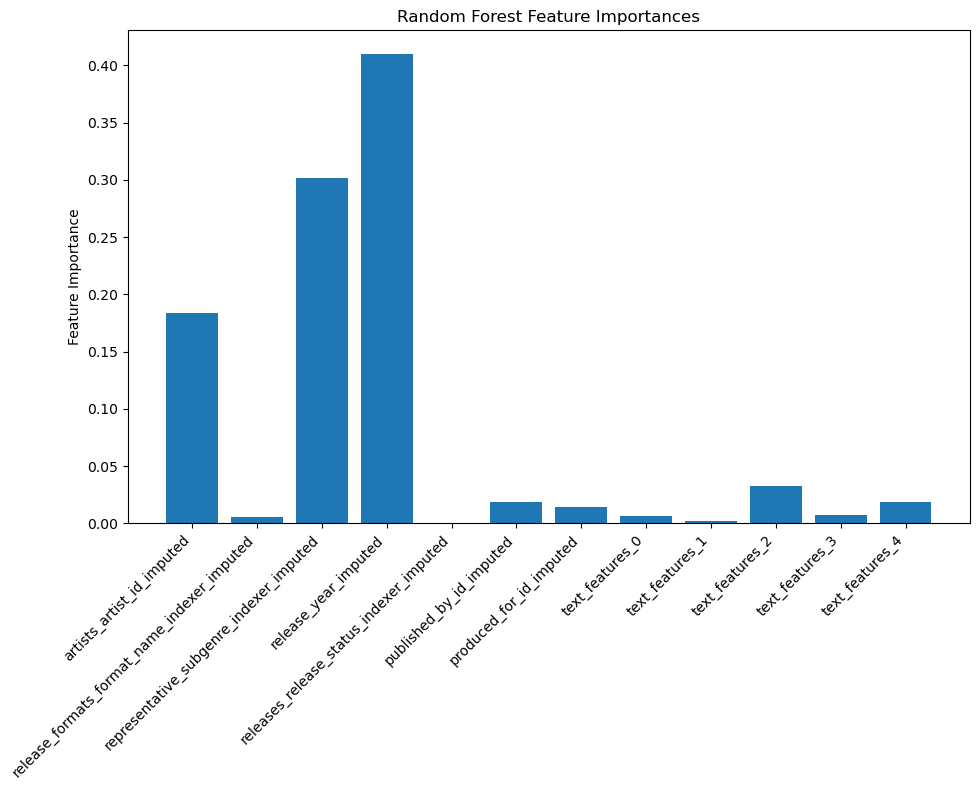

In [ ]:
# get importance values
importances = rf_model.featureImportances.toArray()
n_feats = len(importances)
print("Number of features in model:", n_feats)


numeric_imputed = [
    "artists_artist_id_imputed",
    "release_formats_format_name_indexer_imputed",
    "representative_subgenre_indexer_imputed",
    "release_year_imputed",
    "releases_release_status_indexer_imputed",
    "published_by_id_imputed",
    "produced_for_id_imputed",
]
n_numeric = len(numeric_imputed)

# confirm the number of text features
n_text = n_feats - n_numeric
text_names = [f"text_features_{i}" for i in range(n_text)]

feature_names = numeric_imputed + text_names
assert len(feature_names) == n_feats,

plt.figure(figsize=(10, 8))
plt.bar(range(n_feats), importances)
plt.xticks(
    range(n_feats),
    feature_names,
    rotation=45,
    ha="right"
)
plt.ylabel("Feature Importance")
plt.title("Random Forest Feature Importances")
plt.tight_layout()
plt.show()

Interestingly, we see the release year being the most influential feature in the model, followed by the release style and artist id. The text features do not seem to be as important as previously assumed. It is also noted that the release format (i.e. CD, Vinyl, Digital, etc.), is not an important feature, which would tie in with the assumption that the same release can be released across different formats, and a certain genre does not tend to be released in a certain format.

We will now look into hyperparameter tuning, in order to try and improve our predictions.

### Hyperparameter Tuning to improve Random Forest Classifier

We will be tuning the number of trees and max depth parameters of our Random Forest Classifier, using Grid Search.

In [ ]:
rf = RandomForestClassifier(
    featuresCol="scaled_features",
    labelCol="release_genres_genre_indexer",
    predictionCol="prediction",
    probabilityCol="probability",
    rawPredictionCol="rawPrediction",
    seed=42
)

paramGrid = ParamGridBuilder() \
    .addGrid(rf.numTrees, [10, 20]) \
    .addGrid(rf.maxDepth, [5, 10]) \
    .build()


evaluator = MulticlassClassificationEvaluator(
    labelCol="release_genres_genre_indexer",
    predictionCol="prediction",
    metricName="accuracy"
)

cv = CrossValidator(
    estimator=rf,
    estimatorParamMaps=paramGrid,
    evaluator=evaluator,
    numFolds=3,
    parallelism=4,
    seed=42
)

cvModel = cv.fit(scaled_train)

best_rf = cvModel.bestModel
train_preds = best_rf.transform(scaled_train)
test_preds  = best_rf.transform(scaled_test)

train_acc = evaluator.evaluate(train_preds)
test_acc  = evaluator.evaluate(test_preds)

print(f"Tuned RF Train Accuracy: {train_acc:.4f}")
print(f"Tuned RF Test  Accuracy: {test_acc:.4f}")

25/04/27 00:26:45 WARN DAGScheduler: Broadcasting large task binary with size 1239.7 KiB
25/04/27 00:27:05 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/04/27 00:27:08 WARN DAGScheduler: Broadcasting large task binary with size 1141.8 KiB
25/04/27 00:27:20 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
25/04/27 00:27:20 WARN DAGScheduler: Broadcasting large task binary with size 1820.3 KiB
25/04/27 00:31:40 WARN DAGScheduler: Broadcasting large task binary with size 1231.6 KiB
25/04/27 00:31:49 WARN DAGScheduler: Broadcasting large task binary with size 1138.5 KiB
25/04/27 00:31:52 WARN DAGScheduler: Broadcasting large task binary with size 2.0 MiB
25/04/27 00:32:02 WARN DAGScheduler: Broadcasting large task binary with size 1807.1 KiB
25/04/27 00:32:08 WARN DAGScheduler: Broadcasting large task binary with size 3.3 MiB
25/04/27 00:35:09 WARN DAGScheduler: Broadcasting large task binary with size 2.8 MiB
25/04/27 00:35:11 WARN DAGScheduler:

Tuned RF Train Accuracy: 0.7136
Tuned RF Test  Accuracy: 0.6812


We see that our accuracy has increased by a fair margin with the hyperparameter tuning, with a test accuracy of 0.681. Considering we started with a Logistic Regression model with an accuracy of 0.458, this implies an improvement of approximately 49% in our model's ability to classify genres properly.

In [ ]:
spark.stop()

## Conclusion

Through an extensive analysis of the Discogs music database, we explored the evolution of global music trends across genres, formats, and decades. Our findings revealed notable shifts in genre popularity, with certain styles experiencing rapid growth or decline depending on the era. The analysis of music formats seemed to reflect technological advancements and changing consumer preferences.

Machine learning techniques, including classification and clustering, further enriched our understanding by uncovering hidden patterns and relationships within the data. Text mining helped us surface key themes associated with different musical movements.

Overall, this project demonstrates how big data analytics can illuminate cultural trends and industry transformations over time. The insights gained offer valuable context for understanding not only the past and present state of the music industry, but also potential future directions. With the continuous evolution of music consumption and production, similar analytical approaches will remain crucial for capturing and interpreting these dynamic changes.

Our exploratory data analysis revealed clear patterns in the evolution of global music. The distribution of releases over time reflected major cultural and technological shifts, with notable peaks during periods such as the 1970s and early 2000s. Genre analysis showed how musical tastes diversified significantly across decades, with certain genres emerging, peaking, and sometimes declining rapidly.

Our machine learning model provided valuable insights into the key features that contribute to genre prediction and song classification. With just a limited set of features, we achieved strong predictive performance, attaining a notable accuracy on the test set. Incorporating additional variables in future datasets, such as release_profile, could further enhance the model's accuracy by enriching the input data. Our final machine learning model was able to predict the genre of each release with an accuracy of 0.6812, an increase of ~49% when compared to our baseline model.

By automating genre prediction, our model offers a practical solution for large music streaming platforms like Spotify and Apple Music, reducing the manual effort required to label releases. Furthermore, it can complement existing genre classifications to strengthen and refine music recommendation systems, ultimately improving the user experience.

## Challenges

1. **Multi-valued Columns:**
  Many columns in our dataset contain lists of values. For instance, a single release might be associated with multiple genres or be produced by several companies. This makes it challenging to fully utilize all available information due to the dataset's complexity and size. To address this, we applied tailored strategies for each column. For the genre column, we assumed the first genre in the list is the most representative. For the company_entity column, we focused on two roles most relevant to genre prediction: “published by” and “produced for.”

2. **High Proportion of Missing Values:**
  A significant number of columns contain null or missing values, which can reduce model performance and make data preprocessing more complex. We, therefore, carefully decided which columns to impute, drop, or simplify based on their completeness and relevance.

3. **Lack of Numerical Features:**
  Most of the features in the dataset are categorical, with very few numerical values available. This limits the types of models we can use and increases the complexity of feature engineering, requiring techniques like indexing, one-hot encoding, or embeddings to make the data suitable for machine learning.

4. **Text Processing at Scale:**
  When attempting text analysis on columns such as artist_profile, we found it challenging to extract meaningful tokens and integrate them into our model. Due to the large size of the dataset, typical NLP techniques like tokenization, TF-IDF, or embedding generation became computationally expensive and difficult to scale effectively. As a result, we had to make trade-offs between richness of text features and processing feasibility.

5. **Data Loading and Cluster Management on Releases Data:**
  When attempting to load the release dataset, we encountered two major issues. First, the smaller file available to us was not in a usable format for direct extraction. Second, the larger file was too massive for our Dataproc cluster to fully load into memory. As a result, we had to manually pre-select a subset of relevant columns in advance before ingestion.

## Next Steps

After going through everything in the project, there are some future steps for the project to undergo further study.

1. **Improved Data Collection:** There are lots of null data contained in the dataset, probably because of the data is originally missing or the computation for data inputing leading to the daa missing. In the future work, when collecting data and input the data into the dataset, make sure the data is correctly collected and input into the dataset to reduce the null values contained in the dataset as fewer as possible.

2. **Feature Selection and Engineering:** Feature selection in this project is based on human experience. However, it is not always possible to select all the useful features, and maybe we dropped some features that are useful. The feature engineering can help verify the selection and also improve the model performance with a faster running speed.

3. **Deep Learning:** the dataset contains 90% of the columns with categorical data and text data, and very few are numeric data. Currently in the project, we are using supervised learning models like logistic regression, random forest, etc. However, the way we deal with text data is not working when we add the text data into the model. So for the next steps, using deep learning to deal with the text data and combine the process together can improve the accuracy of the model and expand the usage of the features.

## Generative AI Disclosure

In completing this project, we utilized a couple of Generative AI tools to support various aspects of our work. Below is a detailed account of how these tools were incorporated:

  1. **Research Assistance:** We used ChatGPT to brainstorm approaches, helping us better understand and integrate complex concepts. This was especially helpful as we were figuring out an approach to read the large releases dataset through our dataproc cluster.

  2. **Code Review and Debugging:** ChatGPT provided suggestions for improving our Python code, including optimizing our approach and resolving potential errors. It also assisted us in identifying solutions for issues encountered when loading one of our datasets.

  3. **Proofreading and Grammar Checks:** We used ChatGPT and Grammarly to refine our writing, enhance readability, and ensure grammatical accuracy.

Our team carefully reviewed, edited, and validated all AI-generated content to ensure its accuracy, relevance, and originality, in compliance with academic integrity guidelines.